# Thermodiagrams
In this notebook we use the state variables and functions developed in the [Atmospheric Thermodynamics](atmospheric_thermodynamics.ipynb) notebook to draw two thermodynamic diagrams: an emagram and a skew-T log-P diagram. These diagram are used by meteorologists for weather forecasting. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [11]:
%run -i climate_lib.py

In [15]:
dry_adiabats = dry_adiabats()

In [16]:
t_isohumes = isohumes()

In [17]:
m_adiabats = moist_adiabats()

In [18]:
p = np.linspace(10, 100) * 1000 * units.pascal

In [46]:
radiosonde_path = 'data/pratica_di_mare/2026062412-16245.csv'
radiosonde_df = pd.read_csv(radiosonde_path, index_col=0)
radiosonde_df.head(3)

,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
pressure_hPa,,,,,,,,,
1012.0,32,31.8,20.8,20.8,52,52,15.45,250,2.1
1009.0,59,29.4,19.4,19.4,55,55,14.18,246,2.3
1002.0,122,29.0,19.0,19.0,55,55,13.92,238,2.9


In [34]:
rs_pressure = radiosonde_df.index.to_numpy() * 100 * units.pascal
rs_pressure[:3]

Magnitude,[101200.0 100900.0 100200.0]
Units,pascal


In [42]:
rs_temperature = radiosonde_df['temperature_C'].to_numpy() * units.degK + c.T0
rs_temperature[:3]

Magnitude,[304.96000000000004 302.56 302.16]
Units,kelvin


In [43]:
len(rs_pressure)

130

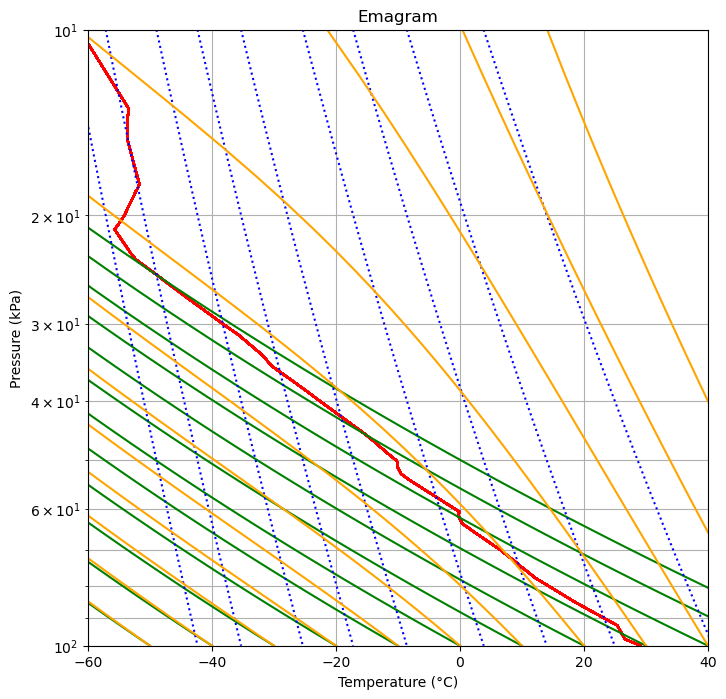

In [45]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot()
ax.grid(visible=True, which='major')
ax.grid(axis='both', visible=True, which='minor')
ax.set_xlim(-60, 40)
ax.set_ylim(100, 10)
ax.yaxis.set_inverted(True)
ax.set_title("Emagram")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (kPa)")
for i in range(len(rs_pressure)):
    ax.semilogy(rs_temperature - c.T0, rs_pressure / 1000, color='red')
for i in range(len(dry_adiabats)):
    ax.semilogy(dry_adiabats[i] - c.T0, p / 1000, color='green')
for i in range(len(t_isohumes)):
    ax.semilogy(t_isohumes[i] - c.T0, p / 1000, color='blue', linestyle=':')
for i in range(len(m_adiabats)):
    ax.semilogy(m_adiabats[i] - c.T0, p / 1000, color='orange')